# CNN-Based Malaria Parasite Recognition in Human Blood Smear Images


### Setup: Local (recommended) or Colab

**Collaborator workflow:**
1. Add the shared data folder to your Drive: open it → **Add shortcut to Drive** → place in **MyDrive** (not "Shared with me").
2. Clone the private repo on your local computer: `git clone https://github.com/iamBolu/COMP-472`
3. Open the repo in VS Code. Use the Colab extension, which will prompt you to connect to your Google Drive.
4. Click "Run All" to execute the notebook. All paths and setup will be handled automatically.

**Alternative (pure Colab):**
1. Upload this notebook to Colab, set **Hardware accelerator = GPU**
2. Add the shared data folder to your Drive as above.
3. Expected path: `MyDrive/COMP472/Project/data/raw`
4. Run cells top to bottom.


In [2]:
import sys
import os
import torch
from pathlib import Path

try:
    import google.colab
    from google.colab import drive

    drive.mount("/content/drive")
    IN_COLAB = True

    # Collaborators: "Add shortcut to Drive" -> place in MyDrive
    DRIVE_PROJECT_ROOT = "/content"

    data_candidates = [
        Path("/content/drive/MyDrive/COMP 472/project/data/raw"),
        Path("/content/drive/MyDrive/COMP472/project/data/raw"),
        Path("/content/drive/MyDrive/COMP 472/Project/data/raw"),
        Path("/content/drive/MyDrive/COMP472/Project/data/raw"),
    ]
    DATA_ROOT = next((p for p in data_candidates if p.exists()), data_candidates[0])

except ImportError:
    IN_COLAB = False
    DRIVE_PROJECT_ROOT = str(Path(os.getcwd()).parent) if Path(os.getcwd()).name == "notebooks" else os.getcwd()
    DATA_ROOT = Path(DRIVE_PROJECT_ROOT) / "data" / "raw"

sys.path.insert(0, DRIVE_PROJECT_ROOT)
os.chdir(DRIVE_PROJECT_ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Runtime: {'Colab' if IN_COLAB else 'Local'} | Device: {device}")
print(f"Code: {DRIVE_PROJECT_ROOT}")
print(f"Data: {DATA_ROOT} (exists: {DATA_ROOT.exists()})")

Mounted at /content/drive
Device: cuda
Runtime: Colab | Device: cuda
Code: /content
Data: /content/drive/MyDrive/COMP472/Project/data/raw (exists: True)


In [4]:
DATASETS = {
    "malaria": os.path.join(DATA_ROOT, "malaria"),
    "iml_malaria": os.path.join(DATA_ROOT, "iml_malaria"),
    "miracle9to9": os.path.join(DATA_ROOT, "miracle9to9"),
}

for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name} -> {dataset_path}")
    print("exists:", os.path.exists(dataset_path))
    print("contents:", os.listdir(dataset_path) if os.path.exists(dataset_path) else "NOT FOUND")


malaria -> /content/drive/MyDrive/COMP472/Project/data/raw/malaria
exists: True
contents: ['.DS_Store', 'test', 'train', 'val']

iml_malaria -> /content/drive/MyDrive/COMP472/Project/data/raw/iml_malaria
exists: True
contents: ['.DS_Store', 'test', 'val', 'train']

miracle9to9 -> /content/drive/MyDrive/COMP472/Project/data/raw/miracle9to9
exists: True
contents: ['.DS_Store', 'train', 'test', 'val']


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Member 1: Data Visualization & Reporting

- Explore all 3 datasets: count images, check sizes, show samples, plot distributions.
- Define shared plotting and reporting functions for all members to use after training.
- Members 3-5 use these functions to visualize training curves, confusion matrices, and classification reports.

### What this section provides to other members:

| Function | What it does | How to use |
|----------|-------------|------------|
| `plot_training_curves(history, title)` | Loss and accuracy curves | `plot_training_curves(resnet_history["malaria"], "ResNet-18")` |
| `plot_confusion_matrix(labels, preds, class_names, title)` | Confusion matrix heatmap | `plot_confusion_matrix(y_true, y_pred, names, "ResNet-18")` |
| `print_classification_report(labels, preds, class_names)` | Precision, recall, F1 per class | `print_classification_report(y_true, y_pred, names)` |

### Output format contract (Members 3, 4, 5 must follow):
```python
# Per architecture, keyed by dataset name:
resnet_history = {}   # history dict with train_loss, val_loss, train_acc, val_acc
resnet_labels  = {}   # numpy array of test labels
resnet_preds   = {}   # numpy array of test predictions
resnet_f1      = {}   # macro F1 float
```

### Step 1 - Imports & Shared Functions

Defines all helper functions used throughout the notebook:
- Image counting, class listing, size sampling
- Plotting: class distribution, split totals, dataset totals, training curves, confusion matrix
- `show_sample_images` for visual inspection

In [6]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

DATASETS = {
    "malaria": os.path.join(DATA_ROOT, "malaria"),
    "iml_malaria": os.path.join(DATA_ROOT, "iml_malaria"),
    "miracle9to9": os.path.join(DATA_ROOT, "miracle9to9"),
}

def get_class_names(dataset_path, split):
    split_path = os.path.join(dataset_path, split)
    return sorted([
        name for name in os.listdir(split_path)
        if os.path.isdir(os.path.join(split_path, name))
    ])

def list_valid_images(folder):
    return sorted([
        name for name in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, name))
        and os.path.splitext(name)[1].lower() in VALID_EXTENSIONS
    ])

def count_images_by_split(dataset_path):
    rows = []
    for split in ["train", "val", "test"]:
        for class_name in get_class_names(dataset_path, split):
            class_path = os.path.join(dataset_path, split, class_name)
            rows.append({
                "split": split,
                "class_name": class_name,
                "image_count": len(list_valid_images(class_path))
            })
    return pd.DataFrame(rows)

def build_phase_a_table(datasets):
    frames = []
    for dataset_name, dataset_path in datasets.items():
        df = count_images_by_split(dataset_path).copy()
        df["dataset"] = dataset_name
        frames.append(df[["dataset", "split", "class_name", "image_count"]])
    return pd.concat(frames, ignore_index=True)

def sample_image_sizes(dataset_path, max_per_class=20):
    rows = []
    for split in ["train", "val", "test"]:
        for class_name in get_class_names(dataset_path, split):
            class_path = os.path.join(dataset_path, split, class_name)
            image_files = list_valid_images(class_path)
            sample_files = image_files[:max_per_class]
            for image_file in sample_files:
                image_path = os.path.join(class_path, image_file)
                with Image.open(image_path) as img:
                    width, height = img.size
                rows.append({
                    "split": split,
                    "class_name": class_name,
                    "width": width,
                    "height": height
                })
    return pd.DataFrame(rows)

def plot_class_distribution(phase_a_df, dataset_name):
    subset = phase_a_df[phase_a_df["dataset"] == dataset_name]
    pivot_df = (
        subset.pivot(index="class_name", columns="split", values="image_count")
        .fillna(0)
        .reindex(sorted(subset["class_name"].unique()))
    )
    pivot_df.plot(kind="bar", figsize=(10, 5))
    plt.title(f"{dataset_name} class distribution by split")
    plt.xlabel("Class")
    plt.ylabel("Image count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_split_totals(split_totals_df):
    pivot_df = (
        split_totals_df.pivot(index="dataset", columns="split", values="image_count")
        .fillna(0)
        .reindex(sorted(split_totals_df["dataset"].unique()))
    )
    pivot_df.plot(kind="bar", figsize=(10, 5))
    plt.title("Split totals by dataset")
    plt.xlabel("Dataset")
    plt.ylabel("Image count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_dataset_totals(dataset_totals_df):
    plt.figure(figsize=(8, 5))
    plt.bar(dataset_totals_df["dataset"], dataset_totals_df["image_count"])
    plt.title("Total images per dataset")
    plt.xlabel("Dataset")
    plt.ylabel("Image count")
    plt.tight_layout()
    plt.show()

def plot_training_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def print_classification_report(labels, preds, class_names):
    report = classification_report(labels, preds, target_names=class_names)
    print(report)

def show_sample_images(dataset_path, split="train", samples_per_class=2):
    class_names = get_class_names(dataset_path, split)
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(4 * samples_per_class, 4 * len(class_names)))

    if len(class_names) == 1:
        axes = np.array([axes])
    if samples_per_class == 1:
        axes = axes.reshape(len(class_names), 1)

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, split, class_name)
        image_files = list_valid_images(class_path)[:samples_per_class]

        for j in range(samples_per_class):
            ax = axes[i, j]
            if j < len(image_files):
                image_path = os.path.join(class_path, image_files[j])
                with Image.open(image_path) as img:
                    ax.imshow(img)
                ax.set_title(f"{class_name}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

### Step 2 - Verify Dataset Paths

Check that every dataset exists and list the class names per split (train/val/test).

In [7]:
# Verify dataset paths and list classes per split
for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name} -> {dataset_path}")
    if os.path.exists(dataset_path):
        for split in ["train", "val", "test"]:
            print(f"  {split} -> {get_class_names(dataset_path, split)}")
    else:
        print("  DATASET PATH NOT FOUND")


malaria -> /content/drive/MyDrive/COMP472/Project/data/raw/malaria
  train -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
  val -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
  test -> ['gametocyte', 'ring', 'schizont', 'trophozoite']

iml_malaria -> /content/drive/MyDrive/COMP472/Project/data/raw/iml_malaria
  train -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
  val -> ['gametocyte', 'ring', 'schizont', 'trophozoite']
  test -> ['gametocyte', 'ring', 'schizont', 'trophozoite']

miracle9to9 -> /content/drive/MyDrive/COMP472/Project/data/raw/miracle9to9
  train -> ['Parasitized', 'Uninfected']
  val -> ['Parasitized', 'Uninfected']
  test -> ['Parasitized', 'Uninfected']


In [8]:
# Quick image sanity check
example_folder = os.path.join(DATASETS["malaria"], "train", "gametocyte")
print("Example folder:", example_folder)
print("Valid images:", len(list_valid_images(example_folder)))
print("First 5 files:", list_valid_images(example_folder)[:5])

sample_image_path = os.path.join(example_folder, list_valid_images(example_folder)[0])
with Image.open(sample_image_path) as img:
    print(f"\nSample: {sample_image_path}")
    print(f"Size: {img.size}  Mode: {img.mode}")

Example folder: /content/drive/MyDrive/COMP472/Project/data/raw/malaria/train/gametocyte
Valid images: 49
First 5 files: ['027ab174-e47a-44f8-b85b-372449eeb7d8.png', '04c07425-57c7-415c-a0bc-36857bbd4049.png', '089c9744-f906-41d8-908d-1e37919a8658.png', '14005767-9296-4b48-8a9d-bbe9b2040005.png', '24879caf-a327-464c-9cd9-e0f3d9161079.png']

Sample: /content/drive/MyDrive/COMP472/Project/data/raw/malaria/train/gametocyte/027ab174-e47a-44f8-b85b-372449eeb7d8.png
Size: (1600, 1200)  Mode: RGB


### Step 3 - Image Counts per Class & Split

Count valid images per class and split for each dataset. Build the full phase A table used for all distribution charts.

In [9]:
# Build full phase A table
phase_a_df = build_phase_a_table(DATASETS)
phase_a_df

,dataset,split,class_name,image_count
0,malaria,train,gametocyte,49
1,malaria,train,ring,108
2,malaria,train,schizont,88
3,malaria,train,trophozoite,326
4,malaria,val,gametocyte,4
5,malaria,val,ring,16
6,malaria,val,schizont,17
7,malaria,val,trophozoite,64
8,malaria,test,gametocyte,3
9,malaria,test,ring,45


In [10]:
# Image counts per class/split for each dataset
for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name}")
    display(count_images_by_split(dataset_path))


malaria


,split,class_name,image_count
0,train,gametocyte,49
1,train,ring,108
2,train,schizont,88
3,train,trophozoite,326
4,val,gametocyte,4
5,val,ring,16
6,val,schizont,17
7,val,trophozoite,64
8,test,gametocyte,3
9,test,ring,45



iml_malaria


,split,class_name,image_count
0,train,gametocyte,81
1,train,ring,41
2,train,schizont,11
3,train,trophozoite,21
4,val,gametocyte,16
5,val,ring,8
6,val,schizont,2
7,val,trophozoite,4
8,test,gametocyte,13
9,test,ring,7



miracle9to9


,split,class_name,image_count
0,train,Parasitized,11713
1,train,Uninfected,11712
2,val,Parasitized,2066
3,val,Uninfected,2067
4,test,Parasitized,7952
5,test,Uninfected,7880


In [11]:
import json

# Training-only class counts for Member 2
training_class_counts_df = (
    phase_a_df[phase_a_df["split"] == "train"]
    .copy()
    .sort_values(["dataset", "class_name"])
    .reset_index(drop=True)
)
display(training_class_counts_df)
training_class_counts_df.to_csv("training_class_counts_member2.csv", index=False)
print("Saved: training_class_counts_member2.csv")

# Shared results template for all members
RESULTS_TEMPLATE = {
    "model_name": None,
    "dataset_name": None,
    "history": {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    },
    "test_metrics": {
        "accuracy": None,
        "f1_macro": None,
        "precision_macro": None,
        "recall_macro": None,
    },
    "labels": [],
    "preds": [],
    "class_names": [],
    "notes": "",
}

with open("results_template.json", "w") as f:
    json.dump(RESULTS_TEMPLATE, f, indent=2)
print("Saved: results_template.json")

,dataset,split,class_name,image_count
0,iml_malaria,train,gametocyte,81
1,iml_malaria,train,ring,41
2,iml_malaria,train,schizont,11
3,iml_malaria,train,trophozoite,21
4,malaria,train,gametocyte,49
5,malaria,train,ring,108
6,malaria,train,schizont,88
7,malaria,train,trophozoite,326
8,miracle9to9,train,Parasitized,11713
9,miracle9to9,train,Uninfected,11712


Saved: training_class_counts_member2.csv
Saved: results_template.json


### Step 4 - Shared Output Files

- `training_class_counts_member2.csv` - training-split class counts used by Member 2 for class weights.
- `results_template.json` - standardized structure for all members' training results.

In [12]:
import shutil

# Derive project path from DATA_ROOT (goes up 2 levels from data/raw)
project_path = str(DATA_ROOT.parent.parent)
os.makedirs(project_path, exist_ok=True)

for fname in ["training_class_counts_member2.csv", "results_template.json"]:
    src = os.path.join(DRIVE_PROJECT_ROOT, fname)
    dst = os.path.join(project_path, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Copied: {fname} -> {dst}")
    else:
        print(f"Skipped (not found): {src}")

Copied: training_class_counts_member2.csv -> /content/drive/MyDrive/COMP472/Project/training_class_counts_member2.csv
Copied: results_template.json -> /content/drive/MyDrive/COMP472/Project/results_template.json


### Step 5 - Image Size Statistics

Sample up to 20 images per class and compute width/height stats per dataset. Helps decide the input size for transforms.

In [13]:
# Image size statistics per dataset
image_size_summary_df = []
for dataset_name, dataset_path in DATASETS.items():
    size_df = sample_image_sizes(dataset_path, max_per_class=20)
    image_size_summary_df.append({
        "dataset": dataset_name,
        "sampled_images": len(size_df),
        "mean_width": round(size_df["width"].mean(), 2),
        "mean_height": round(size_df["height"].mean(), 2),
        "min_width": int(size_df["width"].min()),
        "max_width": int(size_df["width"].max()),
        "min_height": int(size_df["height"].min()),
        "max_height": int(size_df["height"].max())
    })
image_size_summary_df = pd.DataFrame(image_size_summary_df)
image_size_summary_df

,dataset,sampled_images,mean_width,mean_height,min_width,max_width,min_height,max_height
0,malaria,188,1693.32,1249.64,1600,1944,1200,1383
1,iml_malaria,126,1280.00,960.00,1280,1280,960,960
2,miracle9to9,120,141.80,144.75,100,208,97,208


### Step 6 - Summary Tables & Charts

- Split totals and dataset totals tables.
- Bar charts: class distribution per dataset, split totals, dataset totals.
- Sample image grids per dataset.

,dataset,split,image_count
0,iml_malaria,test,25
1,iml_malaria,train,154
2,iml_malaria,val,30
3,malaria,test,94
4,malaria,train,571
5,malaria,val,101
6,miracle9to9,test,15832
7,miracle9to9,train,23425
8,miracle9to9,val,4133


,dataset,image_count
0,iml_malaria,209
1,malaria,766
2,miracle9to9,43390


,dataset,sampled_images,mean_width,mean_height,min_width,max_width,min_height,max_height
0,malaria,188,1693.32,1249.64,1600,1944,1200,1383
1,iml_malaria,126,1280.00,960.00,1280,1280,960,960
2,miracle9to9,120,141.80,144.75,100,208,97,208


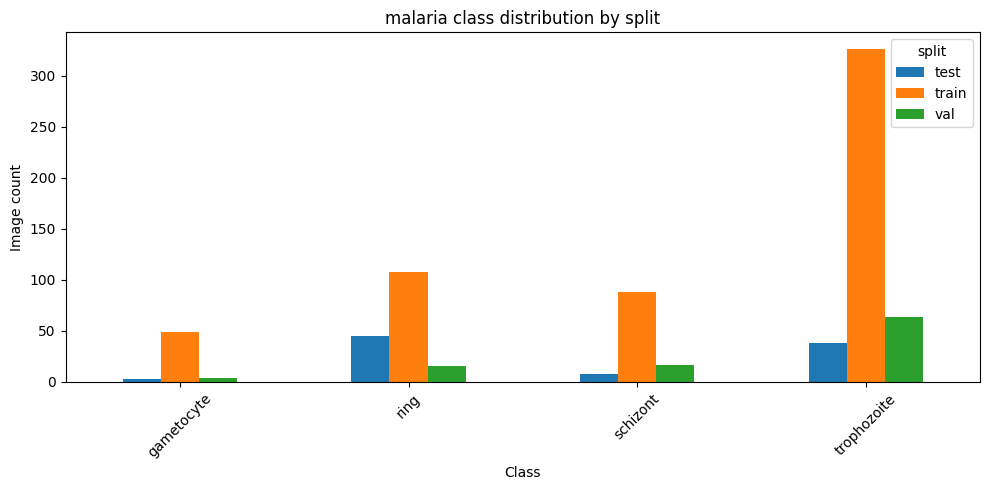

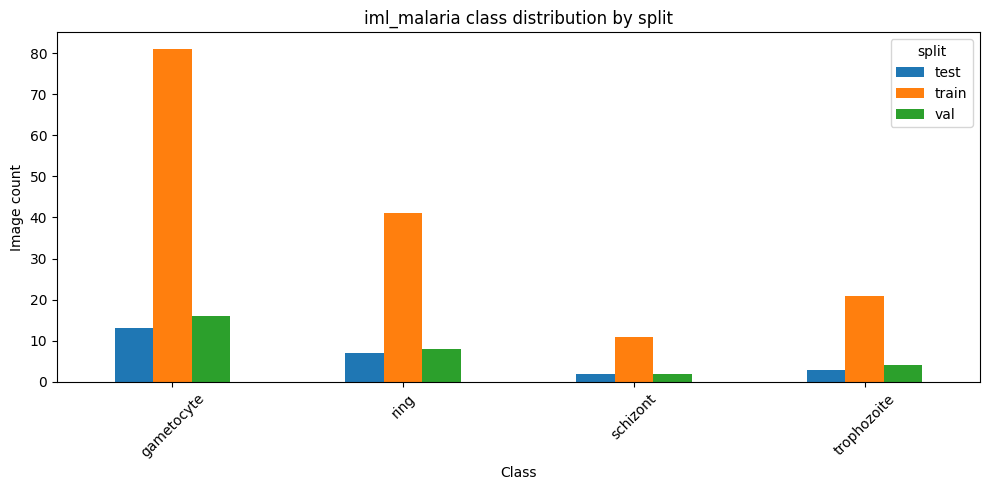

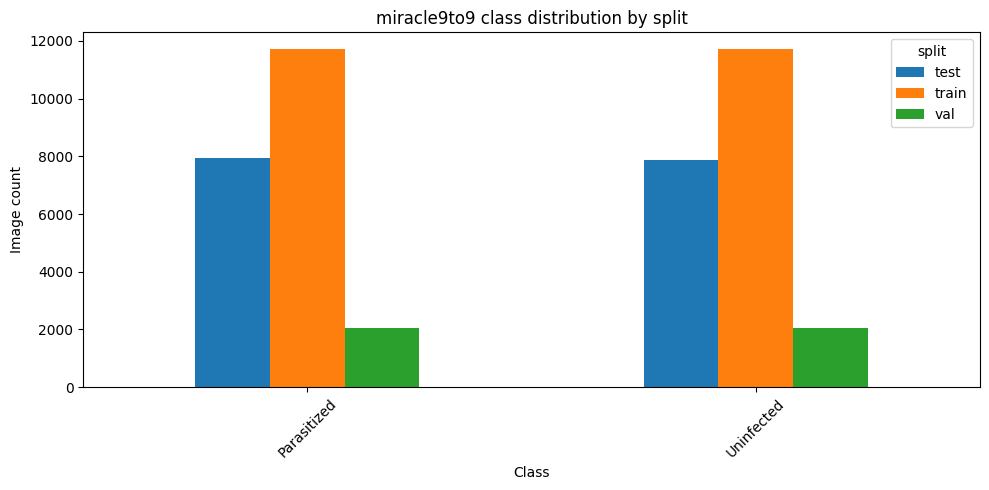

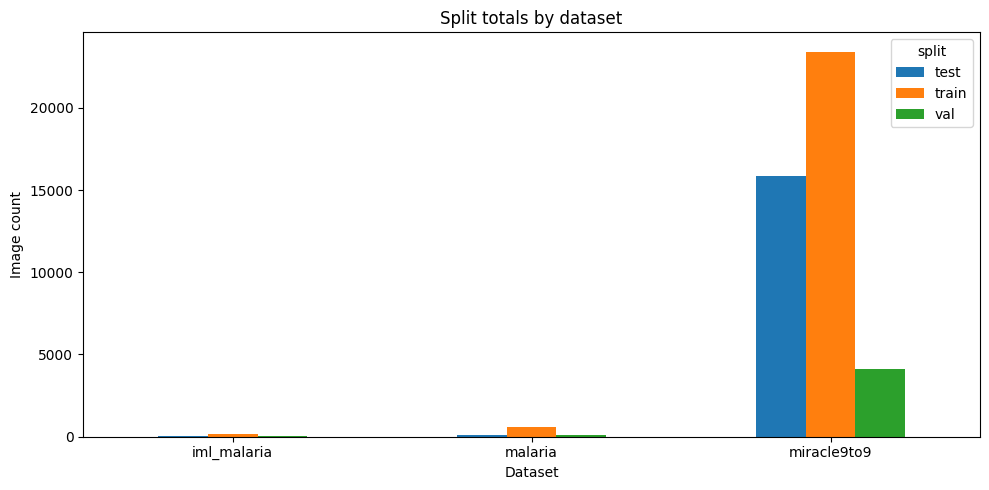

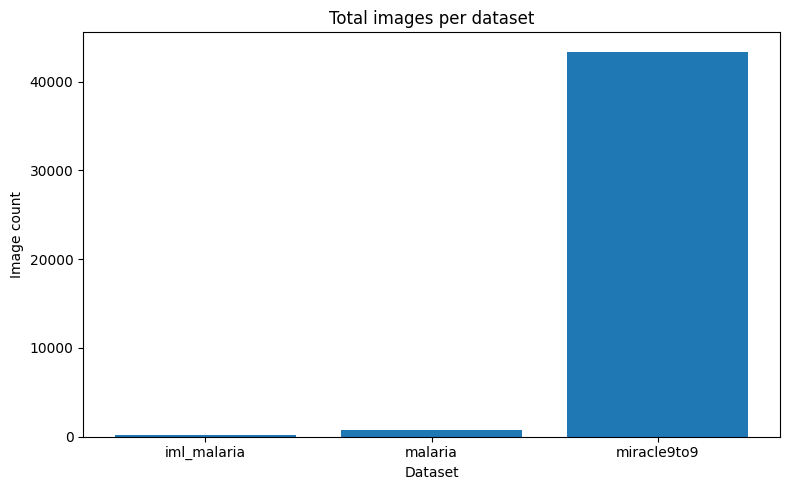

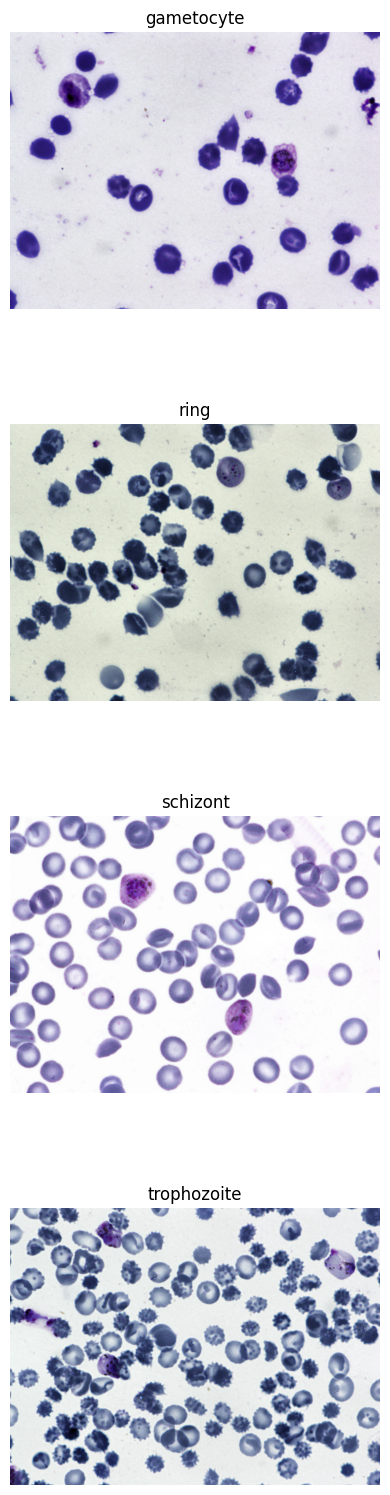

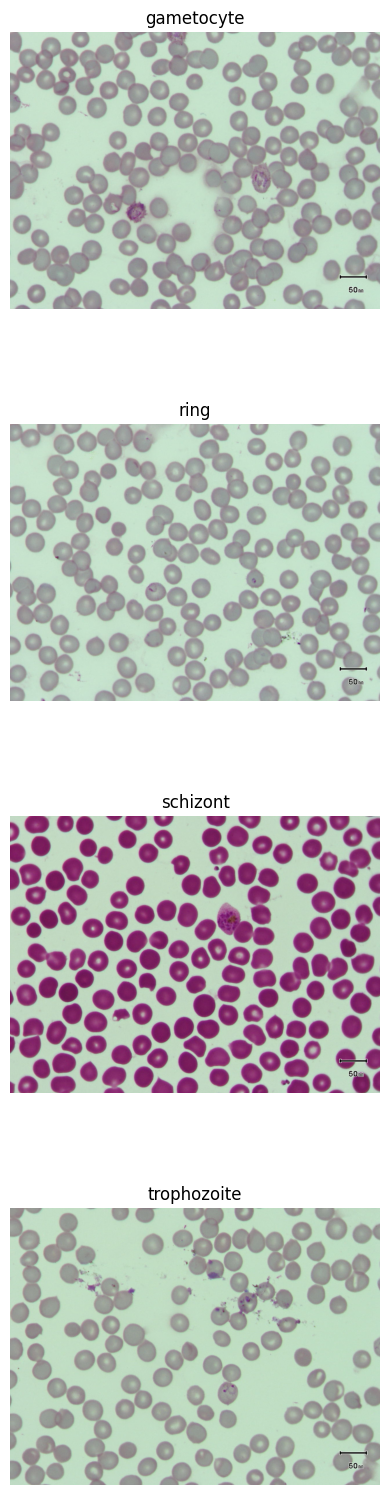

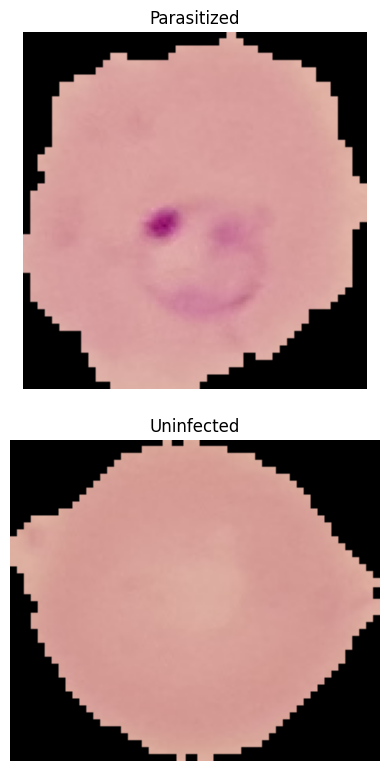

In [14]:
# Summary tables
split_totals_df = (
    phase_a_df.groupby(["dataset", "split"], as_index=False)["image_count"]
    .sum().sort_values(["dataset", "split"]).reset_index(drop=True)
)
dataset_totals_df = (
    phase_a_df.groupby("dataset", as_index=False)["image_count"]
    .sum().sort_values("dataset").reset_index(drop=True)
)
display(split_totals_df)
display(dataset_totals_df)
display(image_size_summary_df)

# All charts
for dataset_name in DATASETS:
    plot_class_distribution(phase_a_df, dataset_name)
plot_split_totals(split_totals_df)
plot_dataset_totals(dataset_totals_df)

# Sample images per dataset
show_sample_images(DATASETS["malaria"], split="train", samples_per_class=1)
show_sample_images(DATASETS["iml_malaria"], split="train", samples_per_class=1)
show_sample_images(DATASETS["miracle9to9"], split="train", samples_per_class=1)

### Member 1 - Summary

- All 3 datasets verified and accessible from Drive.
- Clean image counts computed per class/split. Non-image files filtered out.
- miracle9to9 is largest and balanced; malaria is smaller and imbalanced; iml_malaria is smallest and most imbalanced.
- Image sizes vary most in miracle9to9; iml_malaria is consistent.
- Shared files saved: `training_class_counts_member2.csv`, `results_template.json`.
- Plotting functions ready for Members 3–5 to call after training.

---
## Member 2: Pipeline Implementation

- Build a shared data and model pipeline so all members train on the same data with the same transforms.
- Scan images, create datasets and dataloaders, define transforms, build models, and compute class weights.
- Members 3–5 just call the registries and utilities below - no need to write their own data loading or model setup.

### Step 1 - Imports & Constants

In [15]:
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# DATA_ROOT and device are set in cell 3 based on runtime
IMAGE_INPUT_SIZE = 128
BATCH_SIZE       = 32
NUM_WORKERS      = 0
DATASET_NAMES    = ["miracle9to9", "malaria", "iml_malaria"]  # Defined for use in all sections
IMAGE_EXTENSIONS = {".jpg", ".png"}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"Exists:    {DATA_ROOT.exists()}")


DATA_ROOT: /content/drive/MyDrive/COMP472/Project/data/raw
Exists:    True


### Step 2 - Data Inventory

Scan all images under `data/raw/`, report class counts and imbalance ratios per dataset/split.

In [16]:
all_image_paths = pd.Series([
    path for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
])

if all_image_paths.empty:
    raise FileNotFoundError(f"No images found under '{DATA_ROOT.resolve()}'. Expected: data/raw/<dataset>/<split>/<class>/image.ext")

valid_images_inventory_df = pd.DataFrame({
    "dataset":   all_image_paths.map(lambda p: p.relative_to(DATA_ROOT).parts[0]),
    "split":     all_image_paths.map(lambda p: p.relative_to(DATA_ROOT).parts[1]),
    "class_raw": all_image_paths.map(lambda p: p.parent.name),
    "filepath":  all_image_paths,
})
print(f"Total images: {len(valid_images_inventory_df)}")

class_distribution_df = (
    valid_images_inventory_df
    .groupby(["dataset", "split", "class_raw"])
    .size()
    .reset_index(name="image_count")
)
print("\nClass distribution:")
print(class_distribution_df.to_string(index=False))

split_totals_df = (
    valid_images_inventory_df
    .groupby(["dataset", "split"])
    .size()
    .reset_index(name="total_images")
)
print("\nSplit totals:")
print(split_totals_df.to_string(index=False))

# Simple imbalance ratio: max/min per group
imbalance_df = class_distribution_df.groupby(["dataset", "split"]).agg({"image_count": ["max", "min"]})
imbalance_df["imbalance_ratio"] = (imbalance_df["image_count"]["max"] / imbalance_df["image_count"]["min"]).round(2)
print("\nImbalance ratios (max / min class count):")
print(imbalance_df[["imbalance_ratio"]].to_string())

Total images: 49642

Class distribution:
                     dataset split   class_raw  image_count
                 iml_malaria  test  gametocyte           13
                 iml_malaria  test        ring            7
                 iml_malaria  test    schizont            2
                 iml_malaria  test trophozoite            3
                 iml_malaria train  gametocyte           81
                 iml_malaria train        ring           41
                 iml_malaria train    schizont           11
                 iml_malaria train trophozoite           21
                 iml_malaria   val  gametocyte           16
                 iml_malaria   val        ring            8
                 iml_malaria   val    schizont            2
                 iml_malaria   val trophozoite            4
                     malaria  test  gametocyte            3
                     malaria  test        ring           45
                     malaria  test    schizont            8

In [17]:
SEED = 42
MIRACLE_TARGET_SIZE = 15000

miracle_mask = valid_images_inventory_df["dataset"] == "miracle9to9"

miracle_df = valid_images_inventory_df[miracle_mask].copy()
other_df = valid_images_inventory_df[~miracle_mask].copy()

# Randomly keep only 15,000 miracle9to9 images
miracle_df = miracle_df.sample(n=MIRACLE_TARGET_SIZE, random_state=SEED).reset_index(drop=True)

# Randomly split the kept 15,000 into 70/15/15
miracle_df = miracle_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

n = len(miracle_df)
n_train = int(0.70 * n)   # 10500
n_val = int(0.15 * n)     # 2250
n_test = n - n_train - n_val  # 2250

miracle_df.loc[:n_train - 1, "split"] = "train"
miracle_df.loc[n_train:n_train + n_val - 1, "split"] = "val"
miracle_df.loc[n_train + n_val:, "split"] = "test"

valid_images_inventory_df = pd.concat([other_df, miracle_df], ignore_index=True)

print(
    valid_images_inventory_df[valid_images_inventory_df["dataset"] == "miracle9to9"]
    .groupby("split")
    .size()
    .reset_index(name="count")
    .to_string(index=False)
)

split  count
 test   2250
train  10500
  val   2250


### Step 3 - Transforms

- `training_transforms`: resize → flip → rotation → normalize
- `evaluation_transforms`: resize → normalize (no augmentation)

In [18]:
training_transforms = transforms.Compose([
    transforms.Resize((IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

evaluation_transforms = transforms.Compose([
    transforms.Resize((IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("training_transforms :")
print(training_transforms)
print("\nevaluation_transforms :")
print(evaluation_transforms)


training_transforms :
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-90.0, 90.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

evaluation_transforms :
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### Step 4 - MalariaDataset

Custom `Dataset` class that works for all three datasets.  
Takes a filtered slice of `valid_images_inventory_df` so only validated images are loaded.

In [19]:
class MalariaDataset(Dataset):
    def __init__(self, split_inventory_df, transform=None):
        normalized_class_names = split_inventory_df["class_raw"].str.replace(r"\s+\d+$", "", regex=True)

        unique_classes   = sorted(normalized_class_names.unique())
        class_to_index   = {class_name: index for index, class_name in enumerate(unique_classes)}

        self.image_paths  = split_inventory_df["filepath"].to_numpy()
        self.labels       = normalized_class_names.map(class_to_index).to_numpy()
        self.class_names  = unique_classes
        self.class_to_idx = class_to_index
        self.transform    = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(self.labels[index])


### Step 5 - Datasets, DataLoaders & Class Weights

- `datasets_registry[dataset][split]` -> `MalariaDataset` object
- `dataloaders_registry[dataset][split]` -> `DataLoader` ready for training/eval
- `class_weights_registry[dataset]` -> inverse-frequency weights tensor for `CrossEntropyLoss`

Members 3-5 use `class_weights_registry` to handle imbalanced classes:
```python
criterion = nn.CrossEntropyLoss(weight=class_weights_registry[ds_name])
```

In [20]:
from collections import Counter

SPLIT_TRANSFORMS = {
    "train": training_transforms,
    "val": evaluation_transforms,
    "test": evaluation_transforms,
}

datasets_registry = {
    dataset_name: {
        split: MalariaDataset(
            valid_images_inventory_df[
                (valid_images_inventory_df["dataset"] == dataset_name) &
                (valid_images_inventory_df["split"] == split)
            ].reset_index(drop=True),
            transform=split_transform,
        )
        for split, split_transform in SPLIT_TRANSFORMS.items()
    }
    for dataset_name in DATASET_NAMES
}

dataloaders_registry = {
    dataset_name: {
        split: DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=(split == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            drop_last=(split == "train"),
        )
        for split, dataset in split_datasets.items()
        if len(dataset) > 0
    }
    for dataset_name, split_datasets in datasets_registry.items()
}

def compute_class_weights(dataset, device):
    label_counts = Counter(int(label) for label in dataset.labels)
    total = sum(label_counts.values())
    num_classes = len(dataset.class_names)
    weights = torch.tensor(
        [total / (num_classes * label_counts[i]) for i in range(num_classes)],
        dtype=torch.float32,
        device=device,
    )
    return weights

class_weights_registry = {
    ds_name: compute_class_weights(datasets_registry[ds_name]["train"], device)
    for ds_name in DATASET_NAMES
}

for dataset_name, split_datasets in datasets_registry.items():
    for split_name, dataset in split_datasets.items():
        if len(dataset) == 0:
            print(f"{dataset_name:15s} | {split_name:5s} | SKIPPED since 0 valid images")
            continue
        num_batches = len(dataloaders_registry[dataset_name][split_name])
        print(f"{dataset_name:15s} | {split_name:5s} | {len(dataset):5d} images | {num_batches:4d} batches")

miracle9to9     | train | 10500 images |  328 batches
miracle9to9     | val   |  2250 images |   71 batches
miracle9to9     | test  |  2250 images |   71 batches
malaria         | train |   571 images |   17 batches
malaria         | val   |   101 images |    4 batches
malaria         | test  |    94 images |    3 batches
iml_malaria     | train |   154 images |    4 batches
iml_malaria     | val   |    30 images |    1 batches
iml_malaria     | test  |    25 images |    1 batches


In [21]:
miracle_check_df = (
    valid_images_inventory_df[valid_images_inventory_df["dataset"] == "miracle9to9"]
    .groupby("split")
    .size()
    .reset_index(name="count")
)

miracle_check_df["percent"] = (
    miracle_check_df["count"] / miracle_check_df["count"].sum() * 100
).round(2)

print(miracle_check_df.to_string(index=False))

split  count  percent
 test   2250     15.0
train  10500     70.0
  val   2250     15.0


In [22]:
import numpy as np

In [23]:
def make_split_indices(total_size: int, train_ratio: float = 0.70, val_ratio: float = 0.15, seed: int = SEED):
    rng = np.random.default_rng(seed)

    all_idx = np.arange(total_size)
    rng.shuffle(all_idx)

    train_size = int(total_size * train_ratio)
    val_size = int(total_size * val_ratio)
    test_size = total_size - train_size - val_size

    train_idx = all_idx[:train_size].tolist()
    val_idx = all_idx[train_size:train_size + val_size].tolist()
    test_idx = all_idx[train_size + val_size:].tolist()

    return train_idx, val_idx, test_idx

In [24]:
miracle_only_df = valid_images_inventory_df[
    valid_images_inventory_df["dataset"] == "miracle9to9"
].reset_index(drop=True)

TRAIN_IDX, VAL_IDX, TEST_IDX = make_split_indices(len(miracle_only_df))

print(f"Train / Val / Test sizes: {len(TRAIN_IDX)} / {len(VAL_IDX)} / {len(TEST_IDX)}")
print(f"Total miracle9to9 images: {len(miracle_only_df)}")

Train / Val / Test sizes: 10500 / 2250 / 2250
Total miracle9to9 images: 15000


In [25]:
miracle_only_df = miracle_only_df.copy()

miracle_only_df["split"] = ""
miracle_only_df.loc[TRAIN_IDX, "split"] = "train"
miracle_only_df.loc[VAL_IDX, "split"] = "val"
miracle_only_df.loc[TEST_IDX, "split"] = "test"

other_df = valid_images_inventory_df[
    valid_images_inventory_df["dataset"] != "miracle9to9"
].copy()

valid_images_inventory_df = pd.concat([other_df, miracle_only_df], ignore_index=True)

print(
    valid_images_inventory_df[valid_images_inventory_df["dataset"] == "miracle9to9"]
    .groupby("split")
    .size()
    .reset_index(name="count")
    .to_string(index=False)
)

split  count
 test   2250
train  10500
  val   2250


In [26]:
from collections import Counter

SPLIT_TRANSFORMS = {
    "train": training_transforms,
    "val": evaluation_transforms,
    "test": evaluation_transforms,
}

datasets_registry = {
    dataset_name: {
        split: MalariaDataset(
            valid_images_inventory_df[
                (valid_images_inventory_df["dataset"] == dataset_name) &
                (valid_images_inventory_df["split"] == split)
            ].reset_index(drop=True),
            transform=split_transform,
        )
        for split, split_transform in SPLIT_TRANSFORMS.items()
    }
    for dataset_name in DATASET_NAMES
}

dataloaders_registry = {
    dataset_name: {
        split: DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=(split == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            drop_last=(split == "train"),
        )
        for split, dataset in split_datasets.items()
        if len(dataset) > 0
    }
    for dataset_name, split_datasets in datasets_registry.items()
}

def compute_class_weights(dataset, device):
    label_counts = Counter(int(label) for label in dataset.labels)
    total = sum(label_counts.values())
    num_classes = len(dataset.class_names)
    weights = torch.tensor(
        [total / (num_classes * label_counts[i]) for i in range(num_classes)],
        dtype=torch.float32,
        device=device,
    )
    return weights

class_weights_registry = {
    ds_name: compute_class_weights(datasets_registry[ds_name]["train"], device)
    for ds_name in DATASET_NAMES
}

for dataset_name, split_datasets in datasets_registry.items():
    for split_name, dataset in split_datasets.items():
        if len(dataset) == 0:
            print(f"{dataset_name:15s} | {split_name:5s} | SKIPPED since 0 valid images")
            continue
        num_batches = len(dataloaders_registry[dataset_name][split_name])
        print(f"{dataset_name:15s} | {split_name:5s} | {len(dataset):5d} images | {num_batches:4d} batches")

miracle9to9     | train | 10500 images |  328 batches
miracle9to9     | val   |  2250 images |   71 batches
miracle9to9     | test  |  2250 images |   71 batches
malaria         | train |   571 images |   17 batches
malaria         | val   |   101 images |    4 batches
malaria         | test  |    94 images |    3 batches
iml_malaria     | train |   154 images |    4 batches
iml_malaria     | val   |    30 images |    1 batches
iml_malaria     | test  |    25 images |    1 batches


### Step 6 - Model & Training Utilities

- `build_model(architecture, num_classes)` - creates model on `device`
- `train_model(...)` - trains model, shows batch progress (tqdm), epoch results, and time remaining
- `get_test_predictions(...)` - runs model on test set, returns `(true_labels, predicted_labels)`
- `format_duration(seconds)` - formats seconds as `5m 23s` or `1h 05m 23s`

In [27]:
import torch.nn as nn
import copy, time
import numpy as np
from torchvision import models
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Reproducibility
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

SUPPORTED_ARCHITECTURES = ["resnet18", "vgg16", "mobilenet_v2", "efficientnet_b0"]

def build_model(architecture, num_classes):
    """Create a CNN model from scratch (no pretrained weights) and move to device."""
    if architecture == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif architecture == "vgg16":
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif architecture == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif architecture == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown architecture: {architecture}")
    return model.to(device)

def count_trainable_params(model):
    """Count parameters that require gradient updates."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def format_duration(seconds):
    """Convert seconds to readable string like '5m 23s' or '1h 05m 23s'."""
    minutes, secs = divmod(int(seconds), 60)
    hours, minutes = divmod(minutes, 60)
    return f"{hours}h{minutes:02d}m{secs:02d}s" if hours else f"{minutes}m{secs:02d}s"

# Show parameter counts for each architecture
print(f"{'Architecture':<16} {'Parameters':>12}")
print("-" * 30)
for arch_name in SUPPORTED_ARCHITECTURES:
    temp_model = build_model(arch_name, num_classes=4)
    print(f"{arch_name:<16} {count_trainable_params(temp_model):>12,}")
    del temp_model

def print_progress(phase, batch_idx, total_batches, start_time):
    """Print batch progress every 10% of batches."""
    pct = (batch_idx + 1) / total_batches
    elapsed = time.time() - start_time
    eta = elapsed / (batch_idx + 1) * (total_batches - batch_idx - 1)
    print(f"    {phase}: {batch_idx+1}/{total_batches} ({pct:.0%}) | {format_duration(elapsed)} elapsed | ~{format_duration(eta)} left", flush=True)

def run_train_epoch(model, data_loader, loss_fn, optimizer, device):
    """Train one epoch: forward + backward on every batch. Returns avg loss and accuracy."""
    model.train()
    total_loss, num_correct, num_samples = 0.0, 0, 0
    total_batches = len(data_loader)
    log_interval = max(1, total_batches // 10)  # print every ~10%
    phase_start = time.time()

    for batch_idx, (batch_images, batch_labels) in enumerate(data_loader):
        batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        predictions = model(batch_images)
        loss = loss_fn(predictions, batch_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_images.size(0)
        num_correct += (predictions.argmax(1) == batch_labels).sum().item()
        num_samples += batch_images.size(0)
        # Print progress every ~10% of batches
        if (batch_idx + 1) % log_interval == 0 or (batch_idx + 1) == total_batches:
            print_progress("train", batch_idx, total_batches, phase_start)

    return total_loss / num_samples, num_correct / num_samples

@torch.no_grad()
def run_eval_epoch(model, data_loader, loss_fn, device):
    """Evaluate model (no gradient). Returns avg loss and accuracy."""
    model.eval()
    total_loss, num_correct, num_samples = 0.0, 0, 0
    total_batches = len(data_loader)
    log_interval = max(1, total_batches // 5)  # print every ~20%
    phase_start = time.time()

    for batch_idx, (batch_images, batch_labels) in enumerate(data_loader):
        batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)
        predictions = model(batch_images)
        loss = loss_fn(predictions, batch_labels)
        total_loss += loss.item() * batch_images.size(0)
        num_correct += (predictions.argmax(1) == batch_labels).sum().item()
        num_samples += batch_images.size(0)
        if (batch_idx + 1) % log_interval == 0 or (batch_idx + 1) == total_batches:
            print_progress("val  ", batch_idx, total_batches, phase_start)

    return total_loss / num_samples, num_correct / num_samples

def train_model(model, train_loader, val_loader, loss_fn, optimizer, device, num_epochs, scheduler = None):
    """Full training loop: train + validate each epoch, keep best weights, return history."""
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr_history": []}
    best_val_accuracy = -1.0
    best_model_weights = copy.deepcopy(model.state_dict())
    training_start_time = time.time()

    print(f"  Starting: {num_epochs} epochs x ({len(train_loader)} train + {len(val_loader)} val) batches", flush=True)

    for epoch in range(1, num_epochs + 1):
        epoch_start_time = time.time()
        print(f"\n  --- Epoch {epoch}/{num_epochs} ---", flush=True)

        # Train then validate
        model.train()
        train_loss, train_acc = run_train_epoch(model, train_loader, loss_fn, optimizer, device)
        model.eval()
        val_loss, val_acc = run_eval_epoch(model, val_loader, loss_fn, device)

        #Record the current learning rate to verify the optimization
        current_lr = optimizer.param_groups[0]['lr']

        #Optimizaton step
        if scheduler is not None:
          scheduler.step(val_loss)

        history["lr_history"].append(current_lr)

        # Record metrics
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Save best model based on validation accuracy
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        # Time estimates
        epoch_duration = time.time() - epoch_start_time
        elapsed_so_far = time.time() - training_start_time
        remaining_epochs = num_epochs - epoch
        estimated_time_left = remaining_epochs * (elapsed_so_far / epoch)

        print(f"  Ep {epoch}/{num_epochs} done | "
              f"train {train_loss:.4f}/{train_acc:.4f} | "
              f"val {val_loss:.4f}/{val_acc:.4f} | "
              f"LR: {current_lr:.6f} | "
              f"took {format_duration(epoch_duration)} | "
              f"left ~{format_duration(estimated_time_left)}", flush=True)

    # Restore best weights
    model.load_state_dict(best_model_weights)
    total_training_time = time.time() - training_start_time
    print(f"  Done in {format_duration(total_training_time)} | best val acc {best_val_accuracy:.4f}\n", flush=True)
    return history

@torch.no_grad()
def get_test_predictions(model, data_loader, device):
    """Run model on test set, return (true_labels, predicted_labels) as numpy arrays."""
    model.eval()
    all_true_labels, all_predicted_labels = [], []
    for batch_images, batch_labels in data_loader:
        predictions = model(batch_images.to(device))
        all_predicted_labels.extend(predictions.argmax(1).cpu().numpy())
        all_true_labels.extend(batch_labels.numpy())
    return np.array(all_true_labels), np.array(all_predicted_labels)

print("\nReady: build_model, train_model, get_test_predictions")

Architecture       Parameters
------------------------------
resnet18           11,178,564
vgg16             134,276,932
mobilenet_v2        2,228,996
efficientnet_b0     4,012,672

Ready: build_model, train_model, get_test_predictions


### Member 2 - Summary

Shared pipeline for all members:

| Name | Purpose |
|------|---------|
| `datasets_registry[ds][split]` | Dataset per dataset/split |
| `dataloaders_registry[ds][split]` | DataLoader per dataset/split |
| `class_weights_registry[ds]` | Class weights for `CrossEntropyLoss` |
| `build_model(architecture, n)` | ResNet-18 / VGG-16 / MobileNet-V2 |
| `train_model(...)` | Train loop with tqdm batch bars + epoch/overall time remaining |
| `get_test_predictions(...)` | Returns `(true_labels, predicted_labels)` numpy arrays |
| `format_duration(seconds)` | Format seconds as `5m 23s` for progress display |

---
## Member 3: ResNet-18 Training

- Train ResNet-18 from scratch on all 3 datasets using Member 2's pipeline.
- Uses `fit()`, `collect_predictions()`, `class_weights_registry` from Member 2.
- Outputs: `resnet_history`, `resnet_labels`, `resnet_preds`, `resnet_f1` - consumed by Phase B.
### Available from earlier members
- `build_model("resnet18", num_classes)`
- `train_model()`
- `get_test_predictions()`
- `class_weights_registry`, `dataloaders_registry`, `datasets_registry`
- `plot_training_curves()`, `plot_confusion_matrix()`, `print_classification_report()`

### Tasks
- Train ResNet-18 on all 3 datasets
- Use Adam, lr=0.001, 10 epochs, class weights
- Save: `resnet_history`, `resnet_labels`, `resnet_preds`, `resnet_f1`
- Show all results in Phase B

### Output variables
```python
resnet_history = {}   # training history per dataset
resnet_labels  = {}   # test labels per dataset
resnet_preds   = {}   # test predictions per dataset
resnet_f1      = {}   # macro F1 per dataset
```

In [28]:
# RESNET_EPOCHS = 10
# RESNET_LR     = 0.001

# # Store results per dataset
# resnet_history, resnet_labels, resnet_preds, resnet_f1 = {}, {}, {}, {}
# overall_start = time.time()

# for ds_idx, ds_name in enumerate(DATASET_NAMES, 1):
#     print(f"\n{'='*60}")
#     print(f"ResNet-18 on {ds_name} (dataset {ds_idx}/{len(DATASET_NAMES)})")
#     print(f"{'='*60}")

#     # Get number of classes from training set
#     train_dataset = datasets_registry[ds_name]["train"]
#     num_classes = len(train_dataset.class_names)

#     # Build model, optimizer, weighted loss
#     model     = build_model("resnet18", num_classes)
#     optimizer = torch.optim.Adam(model.parameters(), lr=RESNET_LR)
#     loss_fn   = nn.CrossEntropyLoss(weight=class_weights_registry[ds_name])

#     # Train and save history
#     resnet_history[ds_name] = train_model(
#         model, dataloaders_registry[ds_name]["train"],
#         dataloaders_registry[ds_name]["val"],
#         loss_fn, optimizer, device, RESNET_EPOCHS)

#     # Evaluate on test set
#     true_labels, predicted_labels = get_test_predictions(
#         model, dataloaders_registry[ds_name]["test"], device)
#     resnet_labels[ds_name] = true_labels
#     resnet_preds[ds_name]  = predicted_labels
#     resnet_f1[ds_name]     = f1_score(true_labels, predicted_labels, average="macro")

#     # Overall progress across datasets
#     elapsed = time.time() - overall_start
#     avg_time_per_dataset = elapsed / ds_idx
#     estimated_remaining = (len(DATASET_NAMES) - ds_idx) * avg_time_per_dataset

#     print(f"  Test F1: {resnet_f1[ds_name]:.4f} | "
#           f"overall {ds_idx}/{len(DATASET_NAMES)} done | "
#           f"elapsed {format_duration(elapsed)} | left ~{format_duration(estimated_remaining)}", flush=True)

### Member 3 - Summary

- ResNet-18 trained on all 3 datasets with class weights and best-checkpoint saving.
- Outputs stored in `resnet_history`, `resnet_labels`, `resnet_preds`, `resnet_f1`.
- All plots and reports shown in Phase B (last cell).

---
## Member 4: VGG-16 + Optimization

### Available from earlier members
- `build_model("vgg16", num_classes)`, `train_model()`, `get_test_predictions()` - Member 2
- `class_weights_registry`, `dataloaders_registry`, `datasets_registry` - Member 2
- `plot_training_curves()`, `plot_confusion_matrix()`, `print_classification_report()` - Member 1

### TO DO
1. **Train VGG-16 x 3 datasets** - `lr=0.001`, Adam, 10 epochs, class weights.
2. **LR sweep** on one dataset - train VGG-16 with `lr in {0.01, 0.001, 0.0001}`, log best val acc per LR, pick and justify the best.
3. Add headers and summary markdowns to explain code and expected output. keep the markdowns simple and easy to read

### Output variables (consumed by Phase B)
```python
vgg_history = {}   # vgg_history["malaria"] = history dict
vgg_labels  = {}   # numpy arrays of test labels
vgg_preds   = {}   # numpy arrays of test predictions
vgg_f1      = {}   # macro F1 per dataset
lr_sweep_results = {}  # lr_sweep_results[lr] = best_val_acc
```

### Hints
- Model construction: `Lab_Tutorial_Week_8`, cell 5 (~line 157 for VGG-16)
- LR sweep loop: `Lab_Tutorial_Week_9`, section 11 (~line 3781)

### Requirements
> "Each team should choose at least one of the 9 models trained from scratch and attempt to optimize it through hyperparameter tuning... only from: learning rate, batch size, and loss function."

### For report & video
- Val acc, test acc, macro F1 for each VGG-16 run.
- Table: LR vs val accuracy. Justify best LR.


RUN 1/3: EfficientNet on miracle9to9

  Classes (2):['Parasitized', 'Uninfected']
Train:10500 | Val:2250 | Test:2250

  Classes (2):['Parasitized', 'Uninfected']
  Starting: 10 epochs x (328 train + 71 val) batches

  --- Epoch 1/10 ---
    train: 32/328 (10%) | 9m48s elapsed | ~1h30m43s left
    train: 64/328 (20%) | 19m34s elapsed | ~1h20m45s left
    train: 96/328 (29%) | 29m16s elapsed | ~1h10m43s left
    train: 128/328 (39%) | 39m04s elapsed | ~1h01m02s left
    train: 160/328 (49%) | 48m55s elapsed | ~51m22s left
    train: 192/328 (59%) | 58m55s elapsed | ~41m44s left
    train: 224/328 (68%) | 1h08m42s elapsed | ~31m54s left
    train: 256/328 (78%) | 1h18m45s elapsed | ~22m09s left
    train: 288/328 (88%) | 1h28m39s elapsed | ~12m18s left
    train: 320/328 (98%) | 1h38m36s elapsed | ~2m27s left
    train: 328/328 (100%) | 1h41m00s elapsed | ~0m00s left
    val  : 14/71 (20%) | 5m04s elapsed | ~20m40s left
    val  : 28/71 (39%) | 10m07s elapsed | ~15m33s left
    val  : 42

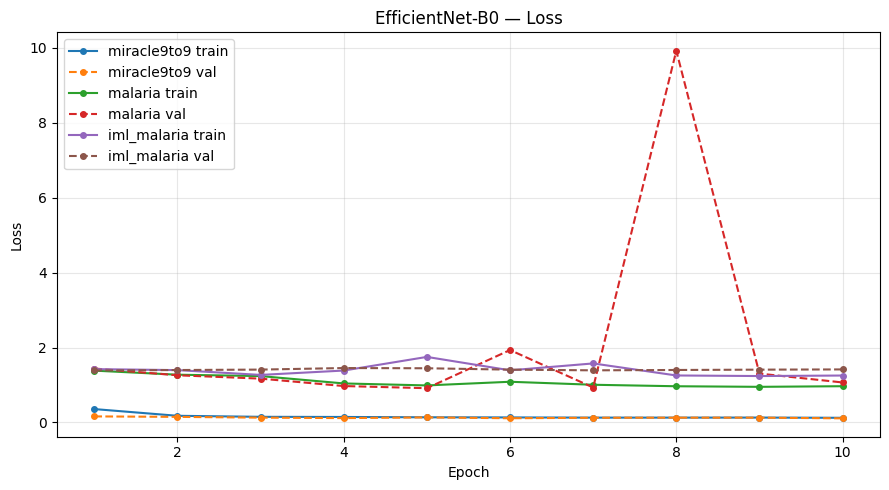

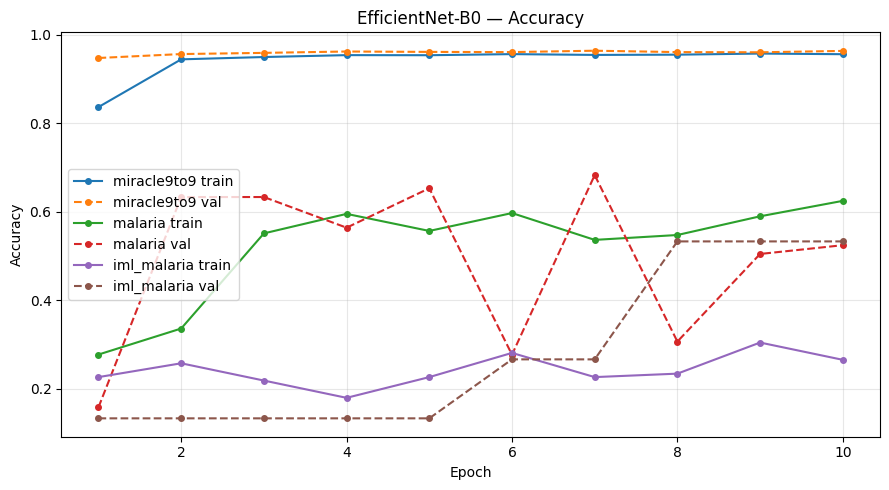

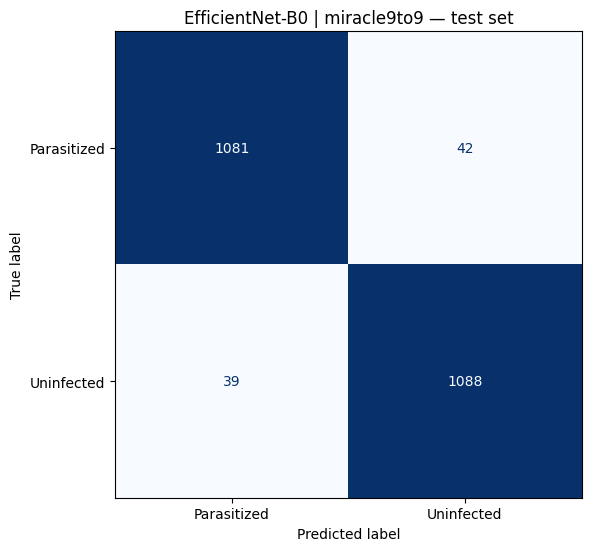

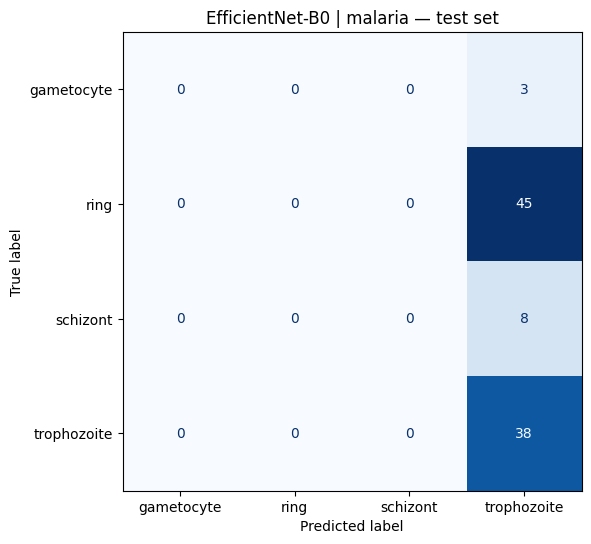

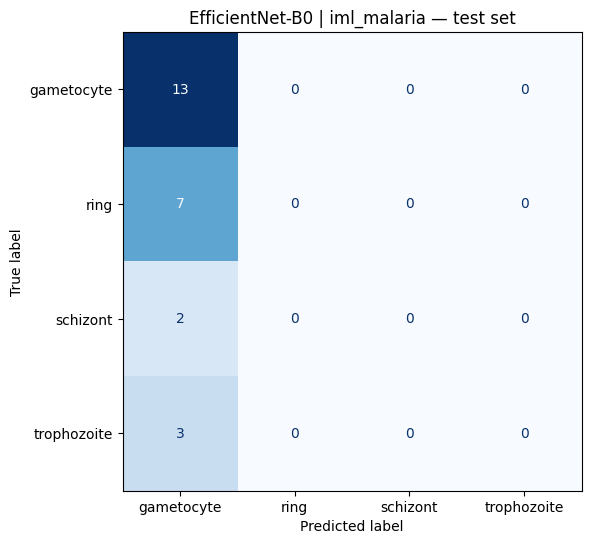


EfficientNet-B0 — Performance Summary



,Learning Rate,Epochs,Best Val Acc,Final Train Loss,Accuracy,Precision,Recall,F1 (macro)
Dataset,,,,,,,,
miracle9to9,0.001,10,0.9644,0.1245,0.9640,0.9640,0.9640,0.9640
malaria,0.001,10,0.6832,0.9679,0.4043,0.1011,0.2500,0.1439
iml_malaria,0.001,10,0.5333,1.2531,0.5200,0.1300,0.2500,0.1711


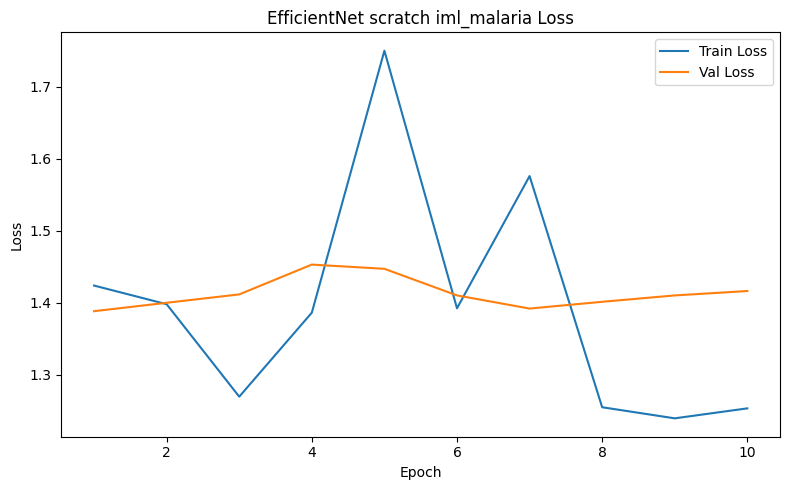

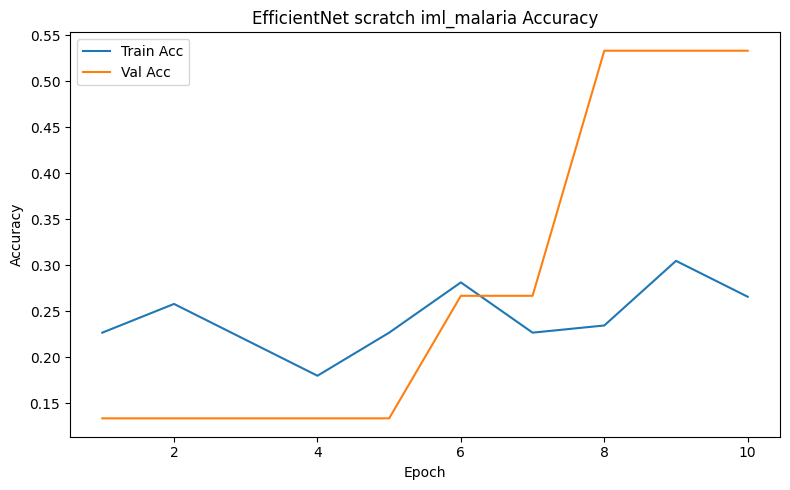

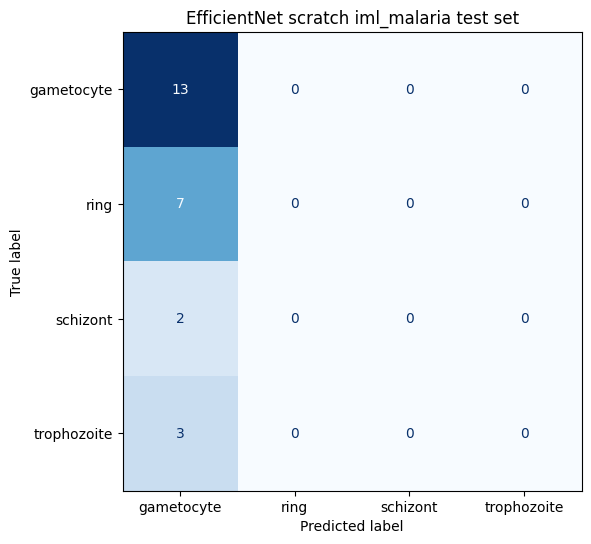

              precision    recall  f1-score   support

  gametocyte       0.52      1.00      0.68        13
        ring       0.00      0.00      0.00         7
    schizont       0.00      0.00      0.00         2
 trophozoite       0.00      0.00      0.00         3

    accuracy                           0.52        25
   macro avg       0.13      0.25      0.17        25
weighted avg       0.27      0.52      0.36        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

EFF_EPOCHS = 10
EFF_LR     = 0.001

#Checkpoint folder on Drive
CHECKPOINT_DIR = Path("/content/drive/MyDrive/COMP472/Project/Checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

eff_history, eff_labels, eff_preds, eff_f1 = {}, {}, {}, {}
overall_start = time.time()

for ds_idx, ds_name in enumerate(DATASET_NAMES, 1):
    #Header for each dataset run
    print(f"\n{'='*60}")
    print(f"RUN {ds_idx}/{len(DATASET_NAMES)}: EfficientNet on {ds_name}")
    print(f"{'='*60}")

    train_dataset = datasets_registry[ds_name]["train"]
    val_dataset   = datasets_registry[ds_name]["val"]
    test_dataset  = datasets_registry[ds_name]["test"]
    num_classes = len(train_dataset.class_names)
    print(f"\n{'='*60}")
    print(f"  Classes ({num_classes}):{train_dataset.class_names}")
    print(f"Train:{len(train_dataset)} | Val:{len(val_dataset)} | Test:{len(test_dataset)}")
    print(f"\n{'='*60}")

    # Get number of classes from training set
    train_dataset = datasets_registry[ds_name]["train"]
    num_classes = len(train_dataset.class_names)
    print(f"  Classes ({num_classes}):{train_dataset.class_names}")

    # Build model, optimizer, weighted loss (Member 2 registry)
    model     = build_model("efficientnet_b0", num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=EFF_LR)
    loss_fn   = nn.CrossEntropyLoss(weight=class_weights_registry[ds_name])

    # Train and save history
    eff_history[ds_name] = train_model(
        model, dataloaders_registry[ds_name]["train"],
        dataloaders_registry[ds_name]["val"],
        loss_fn, optimizer, device, EFF_EPOCHS)

    # Evaluate on test set
    true_labels, predicted_labels = get_test_predictions(
        model, dataloaders_registry[ds_name]["test"], device)
    eff_labels[ds_name] = true_labels
    eff_preds[ds_name]  = predicted_labels
    eff_f1[ds_name]     = f1_score(true_labels, predicted_labels, average="macro")

    # Save model checkpoint after each dataset
    checkpoint_path = CHECKPOINT_DIR / f"efficientnet_b0_{ds_name}.pth"
    torch.save({"model.state_dict()": model.state_dict(),
                "num_classes": num_classes,
                "class_names": train_dataset.class_names,
                "history": eff_history[ds_name],
                "test_labels": true_labels,
                "test_preds": predicted_labels,
                "test_f1_macro": eff_f1[ds_name],
                }, checkpoint_path)
    print(f"  Saved checkpoint: {checkpoint_path}")

    # Overall progress across datasets
    elapsed = time.time() - overall_start
    avg_time_per_dataset = elapsed / ds_idx
    estimated_remaining = (len(DATASET_NAMES) - ds_idx) * avg_time_per_dataset

    print(f"  Test F1: {eff_f1[ds_name]:.4f} | "
          f"overall {ds_idx}/{len(DATASET_NAMES)} done | "
          f"elapsed {format_duration(elapsed)} | left ~{format_duration(estimated_remaining)}", flush=True)

    # ── 1. Training loss graph (all 3 datasets, 1 graph) ──────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for ds_name in DATASET_NAMES:
    h = eff_history[ds_name]
    ax.plot(range(1, EFF_EPOCHS + 1), h["train_loss"],
            label=f"{ds_name} train", marker="o", markersize=4)
    ax.plot(range(1, EFF_EPOCHS + 1), h["val_loss"],
            label=f"{ds_name} val", marker="o", markersize=4, linestyle="--")
ax.set_title("EfficientNet-B0 — Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Validation accuracy graph (all 3 datasets, 1 graph) ────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for ds_name in DATASET_NAMES:
    h = eff_history[ds_name]
    ax.plot(range(1, EFF_EPOCHS + 1), h["train_acc"],
            label=f"{ds_name} train", marker="o", markersize=4)
    ax.plot(range(1, EFF_EPOCHS + 1), h["val_acc"],
            label=f"{ds_name} val", marker="o", markersize=4, linestyle="--")
ax.set_title("EfficientNet-B0 — Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3. Confusion matrix per dataset ───────────────────────────────────────
for ds_name in DATASET_NAMES:
    class_names = datasets_registry[ds_name]["train"].class_names
    plot_confusion_matrix(
        eff_labels[ds_name], eff_preds[ds_name],
        class_names,
        f"EfficientNet-B0 | {ds_name} — test set",
    )

# ── 4. Performance results table ──────────────────────────────────────────
rows = []
for ds_name in DATASET_NAMES:
    y_true = eff_labels[ds_name]
    y_pred = eff_preds[ds_name]
    h      = eff_history[ds_name]
    rows.append({
        "Dataset":        ds_name,
        "Learning Rate":  EFF_LR,
        "Epochs":         EFF_EPOCHS,
        "Best Val Acc":   f"{max(h['val_acc']):.4f}",
        "Final Train Loss":f"{h['train_loss'][-1]:.4f}",
        "Accuracy":       f"{accuracy_score(y_true, y_pred):.4f}",
        "Precision":      f"{precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}",
        "Recall":         f"{recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}",
        "F1 (macro)":     f"{eff_f1[ds_name]:.4f}",
    })

results_df = pd.DataFrame(rows).set_index("Dataset")
print(f"\n{'='*60}")
print(f"EfficientNet-B0 — Performance Summary")
print(f"\n{'='*60}")
display(results_df)

plot_training_curves(eff_history[ds_name], f"EfficientNet scratch {ds_name}")
plot_confusion_matrix(true_labels, predicted_labels, train_dataset.class_names, f"EfficientNet scratch {ds_name} test set")
print_classification_report(true_labels, predicted_labels, train_dataset.class_names)


    # y_true, y_pred, acc, f1 = eval_on_test(model, ds)

    # y_true = eff_labels
    # y_pred = eff_preds
    # f1 = eff_f1

    # plot_training_curves(eff_history[ds], f"EfficientNet_B0 from scratch {ds}")
    # plot_confusion_matrix(y_true,y_pred,datasets_registry[ds]["train"].class_names, f"EfficientNet_B0 from scratch {ds} test set")

In [31]:
# import matplotlib.pyplot as plt

# # --- DATASET CONFIGURATION ---
# data = {
#     "miracle9to9": {
#         "train_loss": [0.4246, 0.1772, 0.1676, 0.1556, 0.1436, 0.1611, 0.1442, 0.1369, 0.1276, 0.1259],
#         "val_loss":   [0.1539, 0.1639, 0.1430, 0.1337, 0.1421, 0.1526, 0.1589, 0.1192, 0.1200, 0.1221],
#         "train_acc":  [0.7951, 0.9451, 0.9470, 0.9522, 0.9529, 0.9507, 0.9526, 0.9533, 0.9582, 0.9582],
#         "val_acc":    [0.9542, 0.9587, 0.9569, 0.9569, 0.9547, 0.9516, 0.9547, 0.9569, 0.9587, 0.9622],
#     },
#     "malaria": {
#         "train_loss": [1.4861, 1.4257, 1.2156, 1.1224, 1.0736, 1.1058, 1.0165, 1.0014, 1.0462, 0.9781],
#         "val_loss":   [1.3716, 1.3465, 1.3729, 0.9975, 1.3057, 1.6910, 1.4238, 1.1021, 1.6951, 0.9960],
#         "train_acc":  [0.2243, 0.2757, 0.3382, 0.3768, 0.3879, 0.4467, 0.5515, 0.5699, 0.5184, 0.5717],
#         "val_acc":    [0.1683, 0.6337, 0.6337, 0.5446, 0.2970, 0.1584, 0.3762, 0.5842, 0.2475, 0.5545],
#     },
#     "iml_malaria": {
#         "train_loss": [1.3873, 1.4087, 1.3288, 1.3029, 1.2955, 1.4103, 1.2142, 1.3213, 1.2021, 1.2252],
#         "val_loss":   [1.3912, 1.3987, 1.4027, 1.3924, 1.3922, 1.3996, 1.4151, 1.4370, 1.4419, 1.4399],
#         "train_acc":  [0.2031, 0.2031, 0.2188, 0.2031, 0.2188, 0.2109, 0.3125, 0.2266, 0.3203, 0.3281],
#         "val_acc":    [0.1333, 0.1333, 0.1333, 0.1333, 0.1333, 0.2667, 0.5333, 0.1333, 0.1333, 0.5333],
#     }
# }

# epochs = range(1, 11)
# fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# # Color constants
# C_TRAIN = "#336699" # Blue
# C_VAL = "#ff9933"   # Orange

# for i, (name, stats) in enumerate(data.items()):
#     # --- LOSS PLOT (Left Column) ---
#     axes[i, 0].plot(epochs, stats["train_loss"], 'o-', color=C_TRAIN, label='Train Loss', linewidth=2)
#     axes[i, 0].plot(epochs, stats["val_loss"], 's--', color=C_VAL, label='Val Loss', linewidth=2)
#     axes[i, 0].set_title(f"{name} — Loss", fontsize=14, fontweight='bold')
#     axes[i, 0].set_xlabel("Epoch")
#     axes[i, 0].set_ylabel("Loss")
#     axes[i, 0].legend()
#     axes[i, 0].grid(True, alpha=0.3)

#     # --- ACCURACY PLOT (Right Column) ---
#     axes[i, 1].plot(epochs, stats["train_acc"], 'o-', color=C_TRAIN, label='Train Acc', linewidth=2)
#     axes[i, 1].plot(epochs, stats["val_acc"], 's--', color=C_VAL, label='Val Acc', linewidth=2)
#     axes[i, 1].set_title(f"{name} — Accuracy", fontsize=14, fontweight='bold')
#     axes[i, 1].set_xlabel("Epoch")
#     axes[i, 1].set_ylabel("Accuracy")
#     axes[i, 1].set_ylim(0, 1.1)
#     axes[i, 1].legend()
#     axes[i, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [32]:
#Optimization on EfficientNet-B0 on miracle9to9 witht 96.22%

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

EFF_EPOCHS = 10
EFF_LR     = 0.001

#Checkpoint folder on Drive
CHECKPOINT_DIR = Path("/content/drive/MyDrive/COMP472/Project/Checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

eff_history, eff_labels, eff_preds, eff_f1 = {}, {}, {}, {}
overall_start = time.time()

for ds_idx, ds_name in enumerate(DATASET_NAMES, 1):
    #Header for each dataset run
    print(f"\n{'='*60}")
    print(f"RUN {ds_idx}/{len(DATASET_NAMES)}: EfficientNet on {ds_name}")
    print(f"{'='*60}")

    train_dataset = datasets_registry[ds_name]["train"]
    val_dataset   = datasets_registry[ds_name]["val"]
    test_dataset  = datasets_registry[ds_name]["test"]
    num_classes = len(train_dataset.class_names)
    print(f"\n{'='*60}")
    print(f"  Classes ({num_classes}):{train_dataset.class_names}")
    print(f"Train:{len(train_dataset)} | Val:{len(val_dataset)} | Test:{len(test_dataset)}")
    print(f"\n{'='*60}")

    # Get number of classes from training set
    train_dataset = datasets_registry[ds_name]["train"]
    num_classes = len(train_dataset.class_names)
    print(f"  Classes ({num_classes}):{train_dataset.class_names}")

    # Build model, optimizer, weighted loss (Member 2 registry)
    model     = build_model("efficientnet_b0", num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=EFF_LR)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
    loss_fn   = nn.CrossEntropyLoss(weight=class_weights_registry[ds_name])

    # Train and save history
    eff_history[ds_name] = train_model(
        model, dataloaders_registry[ds_name]["train"],
        dataloaders_registry[ds_name]["val"],
        loss_fn, optimizer, device, EFF_EPOCHS,scheduler = scheduler)

    # Evaluate on test set
    true_labels, predicted_labels = get_test_predictions(
        model, dataloaders_registry[ds_name]["test"], device)
    eff_labels[ds_name] = true_labels
    eff_preds[ds_name]  = predicted_labels
    eff_f1[ds_name]     = f1_score(true_labels, predicted_labels, average="macro")

    # Save model checkpoint after each dataset
    checkpoint_path = CHECKPOINT_DIR / f"efficientnet_b0_opt_{ds_name}.pth"
    torch.save({"model.state_dict()": model.state_dict(),
                "num_classes": num_classes,
                "class_names": train_dataset.class_names,
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "history": eff_history[ds_name],
                "test_labels": true_labels,
                "test_preds": predicted_labels,
                "test_f1_macro": eff_f1[ds_name],
                }, checkpoint_path)
    print(f"  Saved checkpoint: {checkpoint_path}")

    # Overall progress across datasets
    elapsed = time.time() - overall_start
    avg_time_per_dataset = elapsed / ds_idx
    estimated_remaining = (len(DATASET_NAMES) - ds_idx) * avg_time_per_dataset

    print(f"  Test F1: {eff_f1[ds_name]:.4f} | "
          f"overall {ds_idx}/{len(DATASET_NAMES)} done | "
          f"elapsed {format_duration(elapsed)} | left ~{format_duration(estimated_remaining)}", flush=True)


RUN 1/3: EfficientNet on miracle9to9

  Classes (2):['Parasitized', 'Uninfected']
Train:10500 | Val:2250 | Test:2250

  Classes (2):['Parasitized', 'Uninfected']
  Starting: 10 epochs x (328 train + 71 val) batches

  --- Epoch 1/10 ---
    train: 32/328 (10%) | 0m06s elapsed | ~0m55s left
    train: 64/328 (20%) | 0m11s elapsed | ~0m47s left
    train: 96/328 (29%) | 0m17s elapsed | ~0m41s left
    train: 128/328 (39%) | 0m22s elapsed | ~0m35s left
    train: 160/328 (49%) | 0m28s elapsed | ~0m30s left
    train: 192/328 (59%) | 0m34s elapsed | ~0m24s left
    train: 224/328 (68%) | 0m39s elapsed | ~0m18s left
    train: 256/328 (78%) | 0m45s elapsed | ~0m12s left
    train: 288/328 (88%) | 0m51s elapsed | ~0m07s left
    train: 320/328 (98%) | 0m56s elapsed | ~0m01s left
    train: 328/328 (100%) | 0m58s elapsed | ~0m00s left
    val  : 14/71 (20%) | 0m01s elapsed | ~0m07s left
    val  : 28/71 (39%) | 0m03s elapsed | ~0m05s left
    val  : 42/71 (59%) | 0m05s elapsed | ~0m03s left



──────────────────────────────────────────────────
RUNNING SWEEP: LR = 0.01
──────────────────────────────────────────────────
  Starting: 10 epochs x (328 train + 71 val) batches

  --- Epoch 1/10 ---
    train: 32/328 (10%) | 0m06s elapsed | ~0m59s left
    train: 64/328 (20%) | 0m12s elapsed | ~0m51s left
    train: 96/328 (29%) | 0m17s elapsed | ~0m43s left
    train: 128/328 (39%) | 0m23s elapsed | ~0m36s left
    train: 160/328 (49%) | 0m28s elapsed | ~0m30s left
    train: 192/328 (59%) | 0m34s elapsed | ~0m24s left
    train: 224/328 (68%) | 0m39s elapsed | ~0m18s left
    train: 256/328 (78%) | 0m45s elapsed | ~0m12s left
    train: 288/328 (88%) | 0m51s elapsed | ~0m07s left
    train: 320/328 (98%) | 0m56s elapsed | ~0m01s left
    train: 328/328 (100%) | 0m57s elapsed | ~0m00s left
    val  : 14/71 (20%) | 0m01s elapsed | ~0m06s left
    val  : 28/71 (39%) | 0m03s elapsed | ~0m05s left
    val  : 42/71 (59%) | 0m05s elapsed | ~0m03s left
    val  : 56/71 (79%) | 0m07s elap

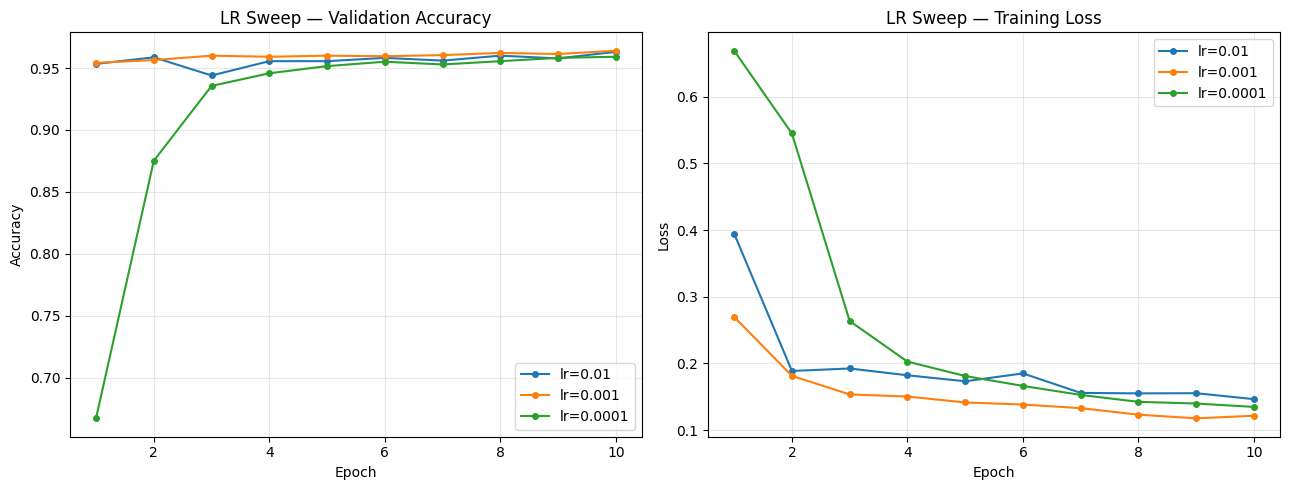

,Best Val Acc,Final Train Loss,Accuracy,Precision,Recall,F1 (macro)
Learning Rate,,,,,,
0.0100,0.9631,0.1466,0.9578,0.9578,0.9578,0.9578
0.0010,0.9640,0.1217,0.9644,0.9645,0.9644,0.9644
0.0001,0.9591,0.1349,0.9604,0.9607,0.9604,0.9604


In [33]:
import copy, pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# --- CONFIGURATION ---
SWEEP_DS     = "miracle9to9"
SWEEP_EPOCHS = 10
LR_STEPS     = [0.01, 0.001, 0.0001]

sweep_train_ds    = datasets_registry[SWEEP_DS]["train"]
sweep_num_cls     = len(sweep_train_ds.class_names)
sweep_loss_fn     = nn.CrossEntropyLoss(weight=class_weights_registry[SWEEP_DS])

lr_histories = {}
lr_results   = []
lr_sweep_results = {} # Define this so the bottom print block works

for lr in LR_STEPS:
    print(f"\n{'─'*50}\nRUNNING SWEEP: LR = {lr}\n{'─'*50}")

    # Build a fresh model for every LR step
    sweep_model = build_model("efficientnet_b0", sweep_num_cls)
    sweep_model.to(device)
    sweep_opt   = torch.optim.Adam(sweep_model.parameters(), lr=lr)

    # Calling your updated train_model (Passing None for scheduler)
    history = train_model(
        sweep_model,
        dataloaders_registry[SWEEP_DS]["train"],
        dataloaders_registry[SWEEP_DS]["val"],
        sweep_loss_fn, sweep_opt, device, SWEEP_EPOCHS,
        scheduler=None # Ensure we use the exact LR for the whole sweep
    )

    lr_histories[lr] = history
    lr_sweep_results[lr] = max(history['val_acc']) # Save for final summary

    # Evaluation
    y_true, y_pred = get_test_predictions(
        sweep_model, dataloaders_registry[SWEEP_DS]["test"], device)

    lr_results.append({
        "Learning Rate":   lr,
        "Best Val Acc":    f"{max(history['val_acc']):.4f}",
        "Final Train Loss":f"{history['train_loss'][-1]:.4f}",
        "Accuracy":        f"{accuracy_score(y_true, y_pred):.4f}",
        "Precision":       f"{precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}",
        "Recall":          f"{recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}",
        "F1 (macro)":      f"{f1_score(y_true, y_pred, average='macro'):.4f}",
    })

# --- VISUALIZATION ---
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(13, 5))
epochs = range(1, SWEEP_EPOCHS + 1)

for lr, history in lr_histories.items():
    ax_acc.plot(epochs, history["val_acc"], label=f"lr={lr}", marker="o", markersize=4)
    ax_loss.plot(epochs, history["train_loss"], label=f"lr={lr}", marker="o", markersize=4)

ax_acc.set_title(f"LR Sweep — Validation Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.grid(True, alpha=0.3)

ax_loss.set_title(f"LR Sweep — Training Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- RESULTS TABLE ---
lr_df = pd.DataFrame(lr_results).set_index("Learning Rate")
display(lr_df)

In [35]:
%pip install thop -q

In [36]:
# Install thop if not already available
try:
    from thop import profile, clever_format
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "thop", "-q"])
    from thop import profile, clever_format

import pandas as pd

# Dummy input matching your pipeline's IMAGE_INPUT_SIZE = 128
input = torch.randn(1, 3, IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE).to(device)

# 4 classes — matches malaria/iml_malaria, miracle9to9 uses 2 but FLOPs
# barely differ by output size so 4 is fine for comparison
FLOP_MODELS = [
    ("ResNet-18",       "resnet18",        4),
    ("EfficientNet-B0", "efficientnet_b0",  4),
    ("MobileNet-V2",    "mobilenet_v2",     4),
]

rows = []
for display_name, arch, n_cls in FLOP_MODELS:
    model = build_model(arch, n_cls)
    model.eval()

    macs, params = profile(model, inputs=(input,), verbose=False)
    flops = macs * 2   # 1 MAC = 1 multiply + 1 add = 2 FLOPs

    macs_fmt,   _ = clever_format([macs],   "%.2f")
    flops_fmt,  _ = clever_format([flops],  "%.2f")
    params_fmt, _ = clever_format([params], "%.2f")

    rows.append({
        "Model":      display_name,
        "MACs":       macs_fmt,
        "FLOPs":      flops_fmt,
        "Parameters": params_fmt,
    })

    print(f"{display_name:20s} | MACs: {macs_fmt:>8} | FLOPs: {flops_fmt:>8} | Params: {params_fmt:>8}")
    del model

print()
display(pd.DataFrame(rows).set_index("Model"))

: 

---
## Member 5: MobileNet-V2 + Transfer Learning + T-SNE

### Available from earlier members
- `build_model("mobilenet_v2", num_classes)`, `train_model()`, `get_test_predictions()` - Member 2
- `class_weights_registry`, `dataloaders_registry`, `datasets_registry` - Member 2
- `plot_training_curves()`, `plot_confusion_matrix()`, `print_classification_report()` - Member 1

### TO DO
1. **Train MobileNet-V2 x 3 datasets** - `lr=0.001`, Adam, 10 epochs, class weights.
2. **TL Run 1** (pick one dataset) - load pretrained MobileNet-V2 (`weights="IMAGENET1K_V1"`), freeze backbone, train head only, 10 epochs.
3. **TL Run 2** (same dataset) - unfreeze full network from Run 1 checkpoint, fine-tune 10 epochs.
4. **T-SNE** - for >= 4 models: swap classifier with `nn.Identity()`, extract test embeddings, run `TSNE(n_components=2)`, scatter plot by class.
5. **Final comparison table** - val acc, test acc, macro F1 for all 11 models as a sorted DataFrame.
3. Add headers and summary markdowns to explain code and expected output. keep the markdowns simple and easy to read

### Output variables (consumed by Phase B)
```python
mobilenet_history, mobilenet_labels, mobilenet_preds, mobilenet_f1 = {}, {}, {}, {}
tl_freeze_history, tl_freeze_labels, tl_freeze_preds, tl_freeze_f1 = {}, {}, {}, {}
tl_finetune_history, tl_finetune_labels, tl_finetune_preds, tl_finetune_f1 = {}, {}, {}, {}
tsne_embeddings = {}  # tsne_embeddings["model_name"] = (x_2d, labels)
final_comparison_df = pd.DataFrame()  # all 11 models sorted by F1
```

### Hints
- Pretrained MobileNet-V2: `Lab_Tutorial_Week_8`, cell 5 (~line 166)
- Freeze/fine-tune: `Lab_Tutorial_Week_9`, section 15 (~line 6966), `build_transfer_model("freeze_head")` / `"fine_tune_last_block"`
- T-SNE: `sklearn.manifold.TSNE(n_components=2)` on extracted feature vectors

### Requirements
> "2 additional models using Transfer Learning (any 2 combinations of dataset+architecture)."
> "Use TSNE or Grad-CAM to visualize the performance of at least 4 different models."

### For report & video
- Scratch vs TL-freeze vs TL-fine-tune comparison table + discussion.
- T-SNE scatter plots in Results & Discussion.
- Final comparison table of all 11 models.
- Conclusion: best model per dataset, key findings, limitations.

---
## Member 1 - Phase B: All Results & Visualizations

This cell is run after all training is complete. It shows:
- Training curves, confusion matrices, classification reports for all 9 scratch models
- LR sweep results (Member 4)
- Transfer learning comparison (Member 5)
- T-SNE scatter plots (Member 5)
- Final comparison table of all 11 models

In [34]:
# # Show results for all scratch models (ResNet-18, VGG-16, MobileNet-V2)
# scratch_model_results = {
#     "ResNet-18":    (resnet_history,    resnet_labels,    resnet_preds,    resnet_f1),
#     "VGG-16":       (vgg_history,       vgg_labels,       vgg_preds,       vgg_f1),
#     "MobileNet-V2": (mobilenet_history, mobilenet_labels, mobilenet_preds, mobilenet_f1),
# }
# for model_name, (history_dict, true_labels_dict, pred_labels_dict, macro_f1_dict) in scratch_model_results.items():
#     for dataset_name in DATASET_NAMES:
#         # Skip if this model was not trained on this dataset
#         if dataset_name not in history_dict:
#             continue
#         title = f"{model_name} - {dataset_name}"
#         class_names = datasets_registry[dataset_name]["train"].class_names
#         print(f"\n{'='*60}\n{title} | Macro F1: {macro_f1_dict[dataset_name]:.4f}\n{'='*60}")
#         # Plot training curves and confusion matrix, print classification report
#         plot_training_curves(history_dict[dataset_name], title)
#         plot_confusion_matrix(true_labels_dict[dataset_name], pred_labels_dict[dataset_name], class_names, title)
#         print_classification_report(true_labels_dict[dataset_name], pred_labels_dict[dataset_name], class_names)

# # Show learning rate sweep results (Member 4)
# if 'lr_sweep_results' in dir() and lr_sweep_results:
#     print("\n" + "="*60 + "\nVGG-16 LR Sweep\n" + "="*60)
#     for lr, best_val_acc in sorted(lr_sweep_results.items()):
#         print(f"  lr={lr} -> best val_acc={best_val_acc:.4f}")

# # Show transfer learning results (Member 5)
# transfer_learning_results = {
#     "TL-Freeze":    (tl_freeze_history,   tl_freeze_labels,   tl_freeze_preds,   tl_freeze_f1),
#     "TL-FineTune":  (tl_finetune_history, tl_finetune_labels, tl_finetune_preds, tl_finetune_f1),
# }
# for tl_name, (history_dict, true_labels_dict, pred_labels_dict, macro_f1_dict) in transfer_learning_results.items():
#     for dataset_name in history_dict:
#         title = f"{tl_name} - {dataset_name}"
#         class_names = datasets_registry[dataset_name]["train"].class_names
#         print(f"\n{'='*60}\n{title} | Macro F1: {macro_f1_dict[dataset_name]:.4f}\n{'='*60}")
#         plot_training_curves(history_dict[dataset_name], title)
#         plot_confusion_matrix(true_labels_dict[dataset_name], pred_labels_dict[dataset_name], class_names, title)
#         print_classification_report(true_labels_dict[dataset_name], pred_labels_dict[dataset_name], class_names)

# # Show T-SNE visualizations (Member 5)
# if 'tsne_embeddings' in dir() and tsne_embeddings:
#     print("\n" + "="*60 + "\nT-SNE Visualizations\n" + "="*60)
#     for model_label, (embedding_2d, label_list) in tsne_embeddings.items():
#         plt.figure(figsize=(8, 6))
#         scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=label_list, cmap="tab10", s=10, alpha=0.7)
#         plt.colorbar(scatter)
#         plt.title(f"T-SNE: {model_label}")
#         plt.tight_layout()
#         plt.show()

# # Show final comparison table (Member 5)
# if 'final_comparison_df' in dir() and not final_comparison_df.empty:
#     print("\n" + "="*60 + "\nFinal Model Comparison\n" + "="*60)
#     display(final_comparison_df.sort_values("f1_macro", ascending=False))